<a href="https://colab.research.google.com/github/tasosquantumcomputing/Machine-Learning/blob/main/DecissionTreeRegressionAndRandomForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Load

In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

data = fetch_california_housing()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['MedHouseVal'] = data.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


EDA

In [2]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


Αν mean ≈ median → συμμετρική κατανομή
Αν mean >> median → δεξιά skewed
Αν mean << median → αριστερά skewed

Μικρό std → οι τιμές είναι κοντά μεταξύ τους

Μεγάλο std → μεγάλη μεταβλητότητα

Σε Decision Trees:

Μεγάλη διασπορά = περισσότερα splits πιθανά

Αν max >> 75% → πιθανό outlier
Αν min << 25% → πιθανό outlier

Το 75% - 25% = IQR
Μεγάλο IQR → μεγάλη διασπορά

Missing Values

In [3]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


Distributions

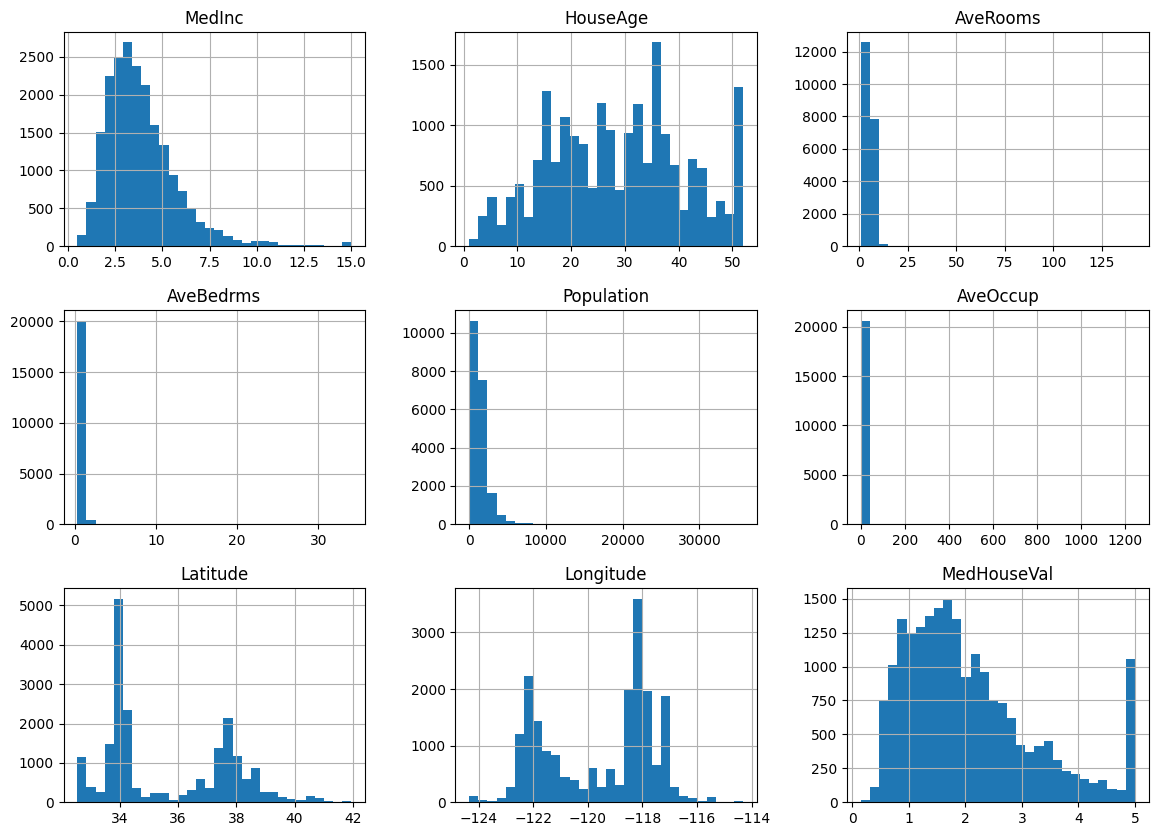

In [4]:
import matplotlib.pyplot as plt

df.hist(bins=30, figsize=(14,10))
plt.show()

Correlation Matrix

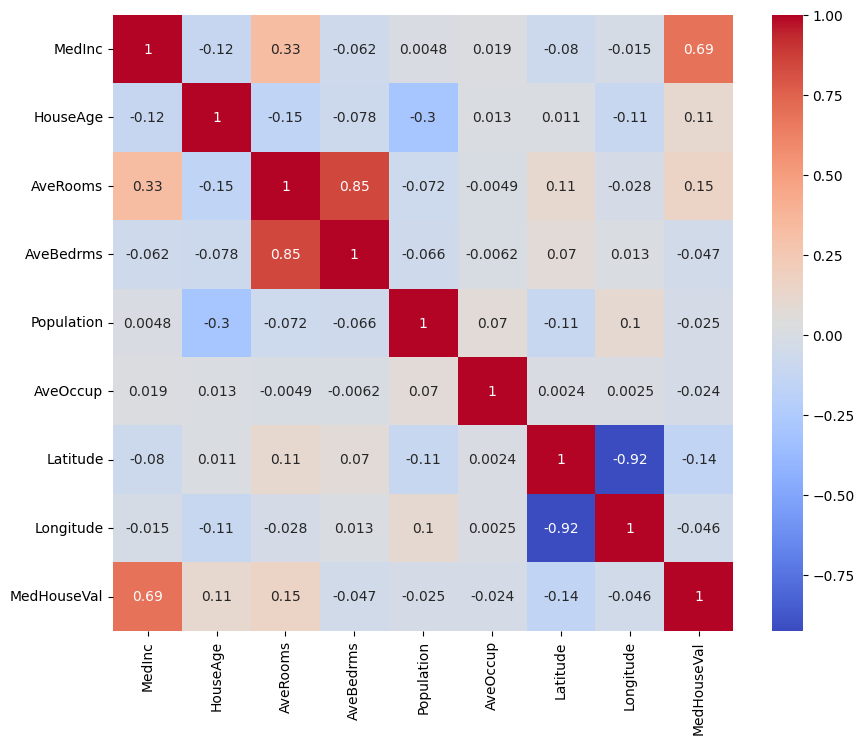

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

<Axes: xlabel='MedInc', ylabel='MedHouseVal'>

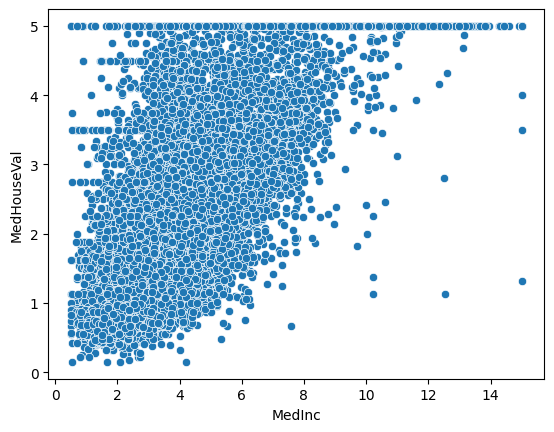

In [6]:
sns.scatterplot(x=df['MedInc'], y=df['MedHouseVal'])

Geographical Visualization

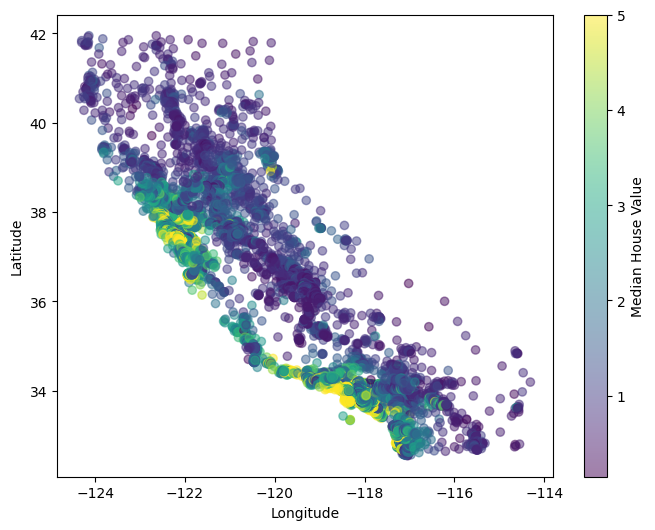

In [7]:
plt.figure(figsize=(8,6))
plt.scatter(df['Longitude'], df['Latitude'],
            c=df['MedHouseVal'], cmap='viridis', alpha=0.5)
plt.colorbar(label='Median House Value')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

Outliers

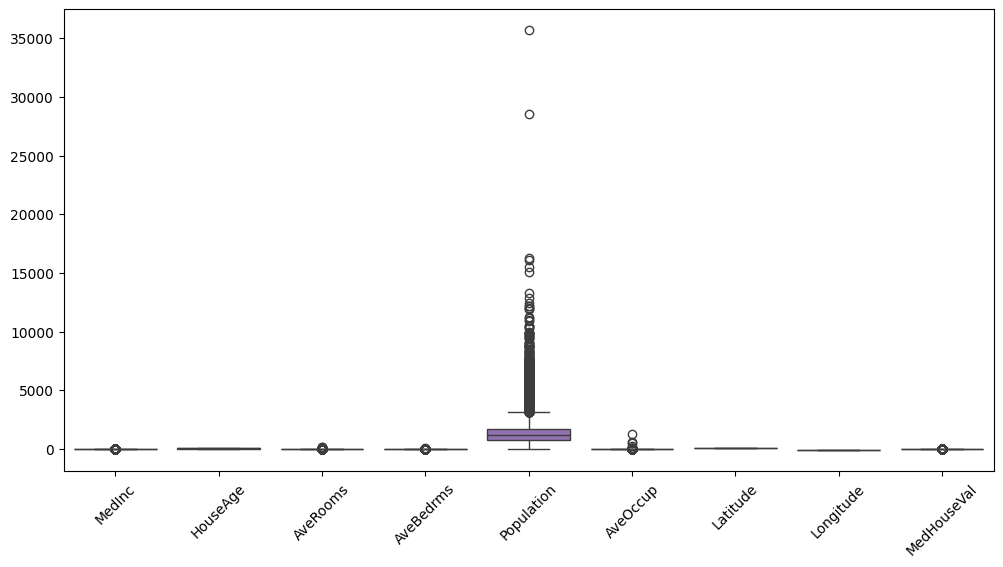

In [8]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

Decision Tree Model

In [9]:
from sklearn.model_selection import train_test_split

X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [11]:
from sklearn.metrics import r2_score, mean_squared_error

y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)

print("Train R²:", r2_score(y_train, y_train_pred))
print("Test R²:", r2_score(y_test, y_test_pred))
print("Test MSE:", mean_squared_error(y_test, y_test_pred))

Train R²: 1.0
Test R²: 0.622075845135081
Test MSE: 0.495235205629094


OVERFITTING!! train r^2 >> test r^2

Overfitting Control????No

In [18]:
tree_limited = DecisionTreeRegressor(
    max_depth=15,
    random_state=42
)

tree_limited.fit(X_train, y_train)

y_test_pred2 = tree_limited.predict(X_test)

print("Test R² (limited depth):", r2_score(y_test, y_test_pred2))

Test R² (limited depth): 0.6460087986104097


To control overfitting in Decision Tree Regression, we use the max_depth parameter, which limits how deep the tree is allowed to grow. When no depth limit is applied, the tree continues splitting until it almost perfectly fits the training data, often resulting in a training R² close to 1.0. However, this typically leads to poor generalization on unseen data, meaning lower performance on the test set — a clear sign of overfitting. By restricting the maximum depth, we reduce the model’s complexity, forcing it to learn broader, more general patterns instead of memorizing noise in the training data. Although this may slightly reduce training accuracy, it often improves test performance and creates a better balance between bias and variance.

Features Importance

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

importance = tree_limited.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(importance_df)

      Feature  Importance
0      MedInc    0.544058
5    AveOccup    0.129410
6    Latitude    0.091827
7   Longitude    0.083360
2    AveRooms    0.050949
1    HouseAge    0.049170
4  Population    0.026476
3   AveBedrms    0.024750


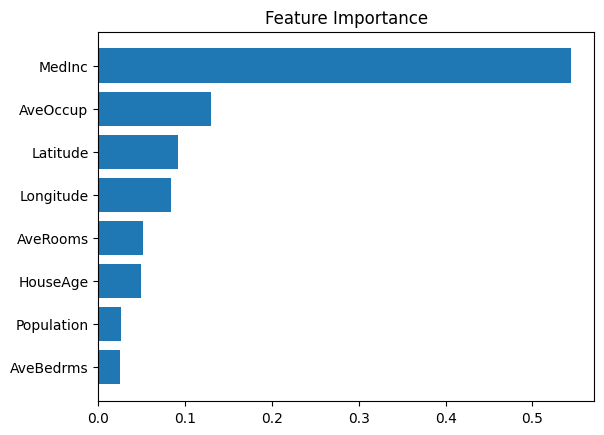

In [20]:
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

Feature importance in Decision Tree Regression measures how much each feature contributes to reducing prediction error in the model. Every time the tree makes a split, it selects the feature that produces the greatest decrease in impurity (for regression, typically a reduction in Mean Squared Error). The total reduction in error caused by each feature is accumulated across all splits and then normalized so that the importance values sum to 1. A higher importance score means that the feature played a more significant role in building the decision rules of the tree. This helps us understand which variables have the strongest influence on predictions, making Decision Trees highly interpretable compared to many other machine learning models.

Application 1: Find the max depth of tree

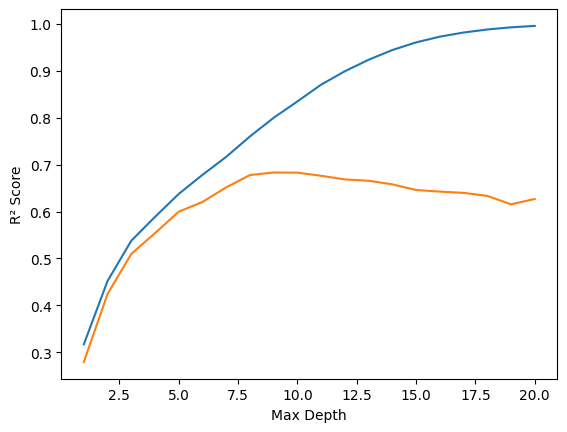

In [21]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

depths = range(1, 21)
train_scores = []
test_scores = []

for d in depths:
    model = DecisionTreeRegressor(max_depth=d, random_state=42)
    model.fit(X_train, y_train)

    train_scores.append(r2_score(y_train, model.predict(X_train)))
    test_scores.append(r2_score(y_test, model.predict(X_test)))

plt.plot(depths, train_scores)
plt.plot(depths, test_scores)
plt.xlabel("Max Depth")
plt.ylabel("R² Score")
plt.show()

Application 2: Min sample split -> Bigger values -> more general(better) model

In [22]:
model = DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=20,
    random_state=42
)

Random Forest

In [24]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

print("Train R²:", r2_score(y_train, y_train_pred))
print("Test R²:", r2_score(y_test, y_test_pred))
print("Test MSE:", mean_squared_error(y_test, y_test_pred))

Train R²: 0.9735726320302575
Test R²: 0.8051230593157366
Test MSE: 0.2553684927247781


In [25]:
print("Decision Tree R²:",
      r2_score(y_test, tree_limited.predict(X_test)))

print("Random Forest R²:",
      r2_score(y_test, rf.predict(X_test)))

Decision Tree R²: 0.6460087986104097
Random Forest R²: 0.8051230593157366


Επειδή κάνει averaging πολλών trees → μειώνει variance.